# analysis.host-range

In this analysis, we want to quantify the relationships between bacteria host range and other ranges in the system (virus host range, bacteria range, virus range.)

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
import seaborn as sns
from scipy import stats
import numpy as np
import powerlaw
import networkx as nx
from scipy.stats import kruskal, mannwhitneyu
from yaml import load, Loader
from daforfer import DaforferDB
from miripvir25.statistics import mann_whitney_posthoc
conf = load(open("conf.yaml"), Loader)
db = DaforferDB(conf['database'])
si = DaforferDB(conf['si'])
si.toc()

┌─────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│  name   │                                                        description                                                        │
│ varchar │                                                          varchar                                                          │
├─────────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ TableS1 │ Table S1: Library sites and context                                                                                       │
│ TableS2 │ This table summarizes most of the information of our detected OTUs, including host_range, site_range, habitat_range, etc. │
│ TableS3 │ Site-level diversity and number of cooccurring virus-bacteria                                                             │
│ TableS4 │ Habitat-level diversity and number o

In [39]:
db.toc().df()

,name,description
0,D_sites,This table contains key information about each...
1,D_bacteriaHits,This table contains all the MOTUS hits obtaine...
2,D_PABHits,This table contains all the PAB MOTUS hits. It...
3,d_TableS1,Table S1: Library sites and context
4,D_PABOTUs,This table summarizes most of the information ...
5,D_virusHits,This table contains all the virus hits. It con...
6,D_coocDetections,Library code and number of cooccurring pairs d...
7,D_coocPairDetections,Number of cooccurring pairs per library. Dedup...
8,D_Site_level_div,Site-level diversity and number of cooccurring...
9,D_Habitat_level_div,Habitat-level diversity and number of cooccurr...


## Host range calculations

We compute the host range simply as the number of hosts that a given bacteria can infect.

In [40]:
metadata = db.conn.sql('SELECT * FROM D_sites').df()
bacteria_hits = db.conn.sql('SELECT * FROM D_PABHits').df()
bacteria_hits = pd.merge(metadata, bacteria_hits, on='library', how='left').dropna(subset='taxid')
bacteria_hits['taxid'] = bacteria_hits['taxid'].astype(int)
bacteria_host_range = bacteria_hits.value_counts(
    ['host_taxon', 'scientific_name']
    ).reset_index().value_counts(
        ['scientific_name']
    ).reset_index().rename(columns={'count': 'host_range'})

bacteria_host_range

,scientific_name,host_range
0,Frigoribacterium sp. Leaf164,22
1,Pseudomonas lutea,16
2,Rhodococcoides fascians,15
3,Methylobacterium sp. Leaf125,14
4,Duffyella gerundensis,14
...,...,...
122,Erwinia mallotivora,1
123,Enterobacter kobei,1
124,Duganella sp. CF458,1
125,Duganella sp. CF402,1


In [41]:
virus_hits = db.conn.sql('SELECT * FROM D_virusHits').df()
virus_hits = pd.merge(metadata, virus_hits, on='library', how='left')
# virus_hits['taxid'] = virus_hits['taxid'].astype(int)
virus_host_range = virus_hits.value_counts(
    ['host_taxon', 'scientific_name']
    ).reset_index().value_counts(
        ['scientific_name']
    ).reset_index().rename(columns={'count': 'host_range'})

virus_host_range

,scientific_name,host_range
0,Cucumber mosaic virus RNA 3,83
1,Tobacco mild green mosaic virus,65
2,Pelargonium zonate spot virus RNA 3,58
3,Tobacco mosaic virus,52
4,Rubus chlorotic mottle virus,50
...,...,...
153,Potato leafroll virus,1
154,Petunia asteroid mosaic virus,1
155,Cucumber leaf spot virus,1
156,Pepper cryptic virus 2,1


In [44]:
assert(virus_host_range.describe().loc['count', 'host_range'] == 158)
print("Virus Max Host Range = ", virus_host_range.describe().loc['max', 'host_range'])
print("Virus Median Host Range = ", virus_host_range.describe().loc['50%', 'host_range'])
print("Virus Min Host Range = ", virus_host_range.describe().loc['min', 'host_range'])
print("Virus that only have one host =", len(virus_host_range.query('host_range == 1')))

db.add_value(
    "Virus_Max_Host_Range", "Maximum host range observed in virus", int(virus_host_range.describe().loc['max', 'host_range']), "INTEGER"
)
db.add_value(
    "Virus_Median_Host_Range", "Maximum host range observed in virus", int(virus_host_range.describe().loc['50%', 'host_range']), "INTEGER"
)
db.add_value(
    "Virus_Min_Host_Range", "Maximum host range observed in virus", int(virus_host_range.describe().loc['min', 'host_range']), "INTEGER"
)
db.add_value(
    "Virus_Only_One_Host", "Virus whose host range is equal to one", len(virus_host_range.query('host_range == 1')), "INTEGER"
)

Virus Max Host Range =  83.0
Virus Median Host Range =  2.0
Virus Min Host Range =  1.0
Virus that only have one host = 63


In [45]:
assert(bacteria_host_range.describe().loc['count', 'host_range'] == 127)
print("PAB Max Host Range = ", bacteria_host_range.describe().loc['max', 'host_range'])
print("PAB Median Host Range = ", bacteria_host_range.describe().loc['50%', 'host_range'])
print("PAB Min Host Range = ", bacteria_host_range.describe().loc['min', 'host_range'])

db.add_value(
    "PAB_Max_Host_Range", "Maximum host range observed in PAB", int(bacteria_host_range.describe().loc['max', 'host_range']), "INTEGER"
)
db.add_value(
    "PAB_Median_Host_Range", "Maximum host range observed in PAB", int(bacteria_host_range.describe().loc['50%', 'host_range']), "INTEGER"
)
db.add_value(
    "PAB_Min_Host_Range", "Maximum host range observed in PAB", int(bacteria_host_range.describe().loc['min', 'host_range']), "INTEGER"
)
db.add_value(
    "PAB_Only_One_Host", "PAB whose host range is equal to one", len(bacteria_host_range.query('host_range == 1')), "INTEGER"
)

PAB Max Host Range =  22.0
PAB Median Host Range =  2.0
PAB Min Host Range =  1.0


In [46]:
bacteria_host_range['kingdom'] = 'bacteria'
virus_host_range['kingdom'] = 'virus'
host_range = pd.concat([bacteria_host_range, virus_host_range])

db.save_dataframe(host_range, "D_hostRanges", "Bacteria and virus host-ranges")
host_range

Saved D_hostRanges to db.2025-11-17


,scientific_name,host_range,kingdom
0,Frigoribacterium sp. Leaf164,22,bacteria
1,Pseudomonas lutea,16,bacteria
2,Rhodococcoides fascians,15,bacteria
3,Methylobacterium sp. Leaf125,14,bacteria
4,Duffyella gerundensis,14,bacteria
...,...,...,...
153,Potato leafroll virus,1,virus
154,Petunia asteroid mosaic virus,1,virus
155,Cucumber leaf spot virus,1,virus
156,Pepper cryptic virus 2,1,virus


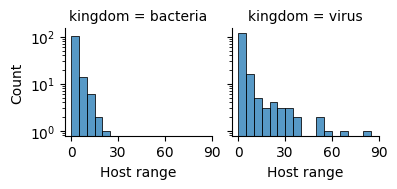

In [47]:

max_range = (host_range['host_range'].max() // 5) + 2
bins = np.arange(0, max_range * 5, 5)
g = sns.displot(data=host_range, x='host_range', col='kingdom', height=2.0, bins=bins)
g.axes[0, 0].set_yscale('log')
g.axes[0, 0].set_xticks([0, 30, 60, 90])
g.set_xlabels("Host range")
g.savefig("figures/displot.host-range.colbykingdom.svg")

## Host Range and Cooccurrence



In [48]:
cooccurrence_network = nx.read_graphml("output/network.coocurrence.virusbact-bylibrary.trans.graphml")
cooccurrence_network.number_of_edges()

57

In [49]:
cooccurrence_network.nodes()

NodeView(('Beet chlorosis virus', 'Duffyella gerundensis', 'Frigoribacterium sp. Leaf164', 'Pseudomonas oryzihabitans', 'Rhodococcoides fascians', 'Beet mild yellowing virus', 'Beet western yellows virus', 'Agrobacterium tumefaciens', 'Arthrobacter sp. Leaf234', 'Pseudomonas sp. Leaf127', 'Sphingomonas sp. Leaf20', 'Cucumber mosaic virus RNA 3', 'Maize dwarf mosaic virus', 'Parietaria mottle virus RNA 3', 'Xanthomonas campestris', 'Pelargonium zonate spot virus RNA 3', 'Pepper mild mottle virus', 'Frigoribacterium sp. Leaf186', 'Pantoea ananatis', 'Sanguibacter sp. Leaf3', 'Rubus chlorotic mottle virus', 'Tobacco mild green mosaic virus', 'Methylobacterium sp. Leaf125', 'Pseudomonas punonensis', 'Rhizobium sp. Leaf311', 'Sphingomonas sp. Leaf208', 'Xylophilus sp. Leaf220', 'Tobacco mosaic virus', 'Curtobacterium flaccumfaciens', 'Rhizobium sp. NFR03', 'Tomato aspermy virus RNA 3', 'Tomato mosaic virus', 'Turnip yellows virus', 'Watermelon mosaic virus', 'Bradyrhizobium elkanii', 'Youca

We compute host-ranges

In [52]:
virus_host_range = virus_hits.drop_duplicates(
    subset=['scientific_name', 'host_taxon']
).value_counts('scientific_name').reset_index()
bacteria_host_range = bacteria_hits.drop_duplicates(
    subset=['scientific_name', 'host_taxon']
).value_counts('scientific_name').reset_index()
virus_host_range['kingdom'] = 'virus'
bacteria_host_range['kingdom'] = 'bacteria'
host_range = pd.concat([virus_host_range, bacteria_host_range])
assert(len(host_range) == 158 + 127)
host_range

,scientific_name,count,kingdom
0,Cucumber mosaic virus RNA 3,83,virus
1,Tobacco mild green mosaic virus,65,virus
2,Pelargonium zonate spot virus RNA 3,58,virus
3,Tobacco mosaic virus,52,virus
4,Rubus chlorotic mottle virus,50,virus
...,...,...,...
122,Erwinia mallotivora,1,bacteria
123,Enterobacter kobei,1,bacteria
124,Duganella sp. CF458,1,bacteria
125,Duganella sp. CF402,1,bacteria


In [53]:
hits = pd.concat([
    bacteria_hits[['host_taxon', 'scientific_name']],
    virus_hits[['host_taxon', 'scientific_name']],
]).drop_duplicates(['host_taxon', 'scientific_name'], keep='first')
hits

,host_taxon,scientific_name
1,Brassica oleracea,Pseudomonas endophytica
2,Brassica oleracea,Micrococcus luteus
5,Sisymbrium runcinatum,Sphingomonas sp. Leaf20
6,Sisymbrium runcinatum,Rhodococcoides fascians
7,Sisymbrium runcinatum,Sphingomonas sp. Leaf17
...,...,...
1649,Zea mays,Rubus chlorotic mottle virus
1650,Zea mays,Tomato mosaic virus
1651,Zea mays,Cucumber mosaic virus RNA 3
1653,Zea mays,Zucchini yellow mosaic virus


In [54]:

organism_cooccurrences = []
for hit in hits.scientific_name.unique():
    if hit in cooccurrence_network.nodes():
        organism_cooccurrences.append({
            "scientific_name": hit,
            "cooc_net_degree": cooccurrence_network.degree[hit]
        })
    else:
        organism_cooccurrences.append({
            "scientific_name": hit,
            "cooc_net_degree": 0
        })
organism_cooccurrences = pd.DataFrame.from_records(organism_cooccurrences)
organism_cooccurrences['cooc_net_degree'] = organism_cooccurrences['cooc_net_degree'].fillna(0)
organism_cooccurrences['does_cooccur'] = organism_cooccurrences['cooc_net_degree'] > 0
host_range_cooccurrence = pd.merge(organism_cooccurrences, host_range,  on='scientific_name')

host_range_cooccurrence
    

,scientific_name,cooc_net_degree,does_cooccur,count,kingdom
0,Pseudomonas endophytica,0,False,2,bacteria
1,Micrococcus luteus,0,False,3,bacteria
2,Sphingomonas sp. Leaf20,1,True,9,bacteria
3,Rhodococcoides fascians,7,True,15,bacteria
4,Sphingomonas sp. Leaf17,0,False,1,bacteria
...,...,...,...,...,...
280,Alfalfa enamovirus 1,0,False,1,virus
281,Pea enation mosaic virus 1,0,False,1,virus
282,Atractylodes mild mottle virus,0,False,1,virus
283,Pepper cryptic virus 2,0,False,1,virus


In [55]:
host_range_cooccurrence = host_range_cooccurrence.rename(columns={'count': 'host_range'})[[
    'scientific_name', 'kingdom', 'cooc_net_degree', 'host_range', 'does_cooccur'
]]

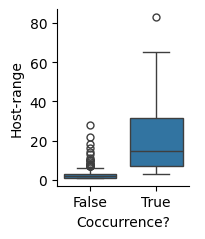

In [56]:
g = sns.catplot(host_range_cooccurrence, x='does_cooccur', y='host_range',  kind='box', height=2.5, aspect=0.8)
g.set_xlabels("Coccurrence?")
g.set_ylabels("Host-range")

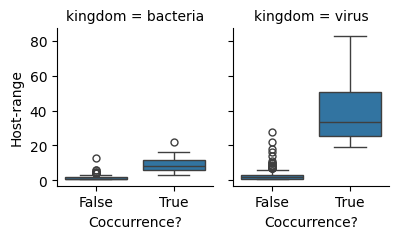

In [57]:
g = sns.catplot(host_range_cooccurrence, x='does_cooccur', y='host_range',  kind='box', height=2.5, aspect=0.8, col='kingdom')
g.set_xlabels("Coccurrence?")
g.set_ylabels("Host-range")

In [58]:
host_range_cooccurrence[['does_cooccur', 'kingdom', 'host_range']].groupby(['kingdom', 'does_cooccur']).mean().round(1).reset_index()

,kingdom,does_cooccur,host_range
0,bacteria,False,1.9
1,bacteria,True,8.9
2,virus,False,3.2
3,virus,True,38.8


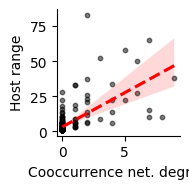

In [59]:
g = sns.lmplot(
    host_range_cooccurrence, x='cooc_net_degree', y='host_range', height=2.0,
    scatter_kws={'alpha':0.5, 's':10, 'color': 'black'}, line_kws={'color': 'red', 'linestyle':'--'}
)
g.set_xlabels("Cooccurrence net. degree")
g.set_ylabels("Host range")
g.savefig("figures/linreg.coocurrence-degree.host-range.svg")

In [60]:
test = stats.linregress(host_range_cooccurrence['cooc_net_degree'], host_range_cooccurrence['host_range'])

test_results = pd.DataFrame.from_records([
    {"key": "title", "value":"Cooccurrence versus host-range"},
    {"key": "test-type", "value":"Regression"},
    {"key": "H0", "value":""},
    {"key": "H1", "value":""},
    {"key": "p-value", "value": test.pvalue}, #type: ignore
    {"key": "significative", "value": test.pvalue < 0.05}, #type: ignore
    {"key": "intercept", "value": test.intercept}, #type: ignore
    {"key": "slope", "value": test.slope}, #type: ignore
    {"key": "r-value", "value": test.rvalue}, #type: ignore
    {"key": "R2", "value": test.rvalue ** 2} #type: ignore

])

db.save_dataframe(
    test_results, table_name="T_coocHostRangeCorr", 
    description="Correlation test between number of cooccurrences and the host-range"
)
test_results


Saved T_coocHostRangeCorr to db.2025-11-17


,key,value
0,title,Cooccurrence versus host-range
1,test-type,Regression
2,H0,
3,H1,
4,p-value,0.0
5,significative,True
6,intercept,3.217847
7,slope,4.85012
8,r-value,0.647992
9,R2,0.419893


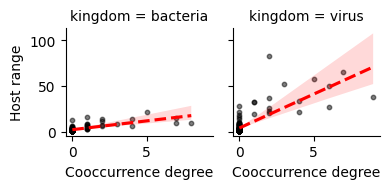

In [61]:
g = sns.lmplot(
    host_range_cooccurrence, x='cooc_net_degree', y='host_range', height=2.0, col='kingdom',
    scatter_kws={'alpha':0.5, 's':10, 'color': 'black'}, line_kws={'color': 'red', 'linestyle':'--'}
)
g.set_xlabels("Cooccurrence degree")
g.set_ylabels("Host range")
g.savefig("figures/linreg.coocurrence-degree.host-range.colbykingdom.svg")

In [62]:
test = stats.linregress(
    host_range_cooccurrence.query('kingdom == "virus"')['cooc_net_degree'], 
    host_range_cooccurrence.query('kingdom == "virus"')['host_range'])

test_results = pd.DataFrame.from_records([
    {"key": "title", "value":"Cooccurrence versus host-range in virus"},
    {"key": "test-type", "value":"Regression"},
    {"key": "H0", "value":""},
    {"key": "H1", "value":""},
    {"key": "p-value", "value": test.pvalue}, #type: ignore
    {"key": "significative", "value": test.pvalue < 0.05}, #type: ignore
    {"key": "intercept", "value": test.intercept}, #type: ignore
    {"key": "slope", "value": test.slope}, #type: ignore
    {"key": "r-value", "value": test.rvalue}, #type: ignore
    {"key": "R2", "value": test.rvalue ** 2} #type: ignore

])

db.save_dataframe(
    test_results, table_name="T_coocHostRangeCorrVir", 
    description="Correlation test between number of cooccurrences and the host-range in Virus"
)
test_results


Saved T_coocHostRangeCorrVir to db.2025-11-17


,key,value
0,title,Cooccurrence versus host-range in virus
1,test-type,Regression
2,H0,
3,H1,
4,p-value,0.0
5,significative,True
6,intercept,4.09352
7,slope,7.424981
8,r-value,0.765305
9,R2,0.585692


In [63]:
test = stats.linregress(
    host_range_cooccurrence.query('kingdom == "bacteria"')['cooc_net_degree'], 
    host_range_cooccurrence.query('kingdom == "bacteria"')['host_range'])

test_results = pd.DataFrame.from_records([
    {"key": "title", "value":"Cooccurrence versus host-range in Bacteria"},
    {"key": "test-type", "value":"Regression"},
    {"key": "H0", "value":""},
    {"key": "H1", "value":""},
    {"key": "p-value", "value": test.pvalue}, #type: ignore
    {"key": "significative", "value": test.pvalue < 0.05}, #type: ignore
    {"key": "intercept", "value": test.intercept}, #type: ignore
    {"key": "slope", "value": test.slope}, #type: ignore
    {"key": "r-value", "value": test.rvalue}, #type: ignore
    {"key": "R2", "value": test.rvalue ** 2} #type: ignore

])

db.save_dataframe(
    test_results, table_name="T_coocHostRangeCorrBact", 
    description="Correlation test between number of cooccurrences and the host-range in Bacteria"
)
test_results


Saved T_coocHostRangeCorrBact to db.2025-11-17


,key,value
0,title,Cooccurrence versus host-range in Bacteria
1,test-type,Regression
2,H0,
3,H1,
4,p-value,0.0
5,significative,True
6,intercept,2.285935
7,slope,1.92432
8,r-value,0.716642
9,R2,0.513575


In [64]:
test_results = []
test = mannwhitneyu(
    host_range_cooccurrence.query('does_cooccur == True')['host_range'],
    host_range_cooccurrence.query('does_cooccur == False')['host_range'],
)

test_results.append(
    {
        "organisms": "all", "statistic": test.statistic, "p-value": test.pvalue
    }
)
test = mannwhitneyu(
    host_range_cooccurrence.query('does_cooccur == True').query('kingdom == "bacteria"')['host_range'],
    host_range_cooccurrence.query('does_cooccur == False').query('kingdom == "bacteria"')['host_range'],
)
test_results.append(
    {
        "organisms": "bacteria", "statistic": test.statistic, "p-value": test.pvalue
    }
)
mannwhitneyu(
    host_range_cooccurrence.query('does_cooccur == True').query('kingdom == "virus"')['host_range'],
    host_range_cooccurrence.query('does_cooccur == False').query('kingdom == "virus"')['host_range'],
)
test_results.append(
    {
        "organisms": "virus", "statistic": test.statistic, "p-value": test.pvalue
    }
)
test_results = pd.DataFrame.from_records(test_results)

db.save_dataframe(
    test_results, table_name="T_coocHostRangeMW", 
    description="Multiple Mann-Whitney tests on the Host-range of cooccurring organisms versus not cooccurring organisms"
)
test_results

Saved T_coocHostRangeMW to db.2025-11-17


,organisms,statistic,p-value
0,all,8945.5,6.856033e-21
1,bacteria,2230.5,6.370211e-13
2,virus,2230.5,6.370211e-13


In [35]:
si.save_dataframe(
    host_range_cooccurrence, 'TableS7',
    'Host range and cooccurrence network degree'
)
host_range_cooccurrence

Saved TableS7 to si.2025-11-17


,scientific_name,kingdom,cooc_net_degree,host_range,does_cooccur
0,Pseudomonas endophytica,bacteria,0,2,False
1,Micrococcus luteus,bacteria,0,3,False
2,Sphingomonas sp. Leaf20,bacteria,1,9,True
3,Rhodococcoides fascians,bacteria,7,15,True
4,Sphingomonas sp. Leaf17,bacteria,0,1,False
...,...,...,...,...,...
280,Alfalfa enamovirus 1,virus,0,1,False
281,Pea enation mosaic virus 1,virus,0,1,False
282,Atractylodes mild mottle virus,virus,0,1,False
283,Pepper cryptic virus 2,virus,0,1,False


In [65]:
db.conn.close()
si.conn.close()